In [1]:
# Load CSV using the local file with a header row
import csv
import numpy as np
filename = 'pima-indians-diabetes_original.csv'
with open(filename, 'r', newline='') as raw_data:
    reader = csv.reader(raw_data)
    next(reader, None)  # skip header
    rows = [row for row in reader]
data = np.array(rows, dtype=float)
print(data.shape)

(768, 9)


In [2]:
from pandas import read_csv
filename = 'pima-indians-diabetes_original.csv'
names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']
data = read_csv(filename, header=0, names=names)
print(data.shape)

(768, 9)


In [3]:
#view first 20 rows
peek = data.head(20)
print(peek)

    preg  plas  pres  skin  test  mass   pedi  age  class
0      6   148    72    35     0  33.6  0.627   50      1
1      1    85    66    29     0  26.6  0.351   31      0
2      8   183    64     0     0  23.3  0.672   32      1
3      1    89    66    23    94  28.1  0.167   21      0
4      0   137    40    35   168  43.1  2.288   33      1
5      5   116    74     0     0  25.6  0.201   30      0
6      3    78    50    32    88  31.0  0.248   26      1
7     10   115     0     0     0  35.3  0.134   29      0
8      2   197    70    45   543  30.5  0.158   53      1
9      8   125    96     0     0   0.0  0.232   54      1
10     4   110    92     0     0  37.6  0.191   30      0
11    10   168    74     0     0  38.0  0.537   34      1
12    10   139    80     0     0  27.1  1.441   57      0
13     1   189    60    23   846  30.1  0.398   59      1
14     5   166    72    19   175  25.8  0.587   51      1
15     7   100     0     0     0  30.0  0.484   32      1
16     0   118

In [4]:
types = data.dtypes
print(types)

preg       int64
plas       int64
pres       int64
skin       int64
test       int64
mass     float64
pedi     float64
age        int64
class      int64
dtype: object


In [5]:
from pandas import set_option
set_option('display.width', 120)
set_option('display.precision', 3)
description = data.describe()
print(description)

          preg     plas     pres     skin     test     mass     pedi      age    class
count  768.000  768.000  768.000  768.000  768.000  768.000  768.000  768.000  768.000
mean     3.845  120.895   69.105   20.536   79.799   31.993    0.472   33.241    0.349
std      3.370   31.973   19.356   15.952  115.244    7.884    0.331   11.760    0.477
min      0.000    0.000    0.000    0.000    0.000    0.000    0.078   21.000    0.000
25%      1.000   99.000   62.000    0.000    0.000   27.300    0.244   24.000    0.000
50%      3.000  117.000   72.000   23.000   30.500   32.000    0.372   29.000    0.000
75%      6.000  140.250   80.000   32.000  127.250   36.600    0.626   41.000    1.000
max     17.000  199.000  122.000   99.000  846.000   67.100    2.420   81.000    1.000


In [6]:
#class distribution
class_counts = data.groupby('class').size()
print(class_counts)

class
0    500
1    268
dtype: int64


In [7]:
#correlation
correlations = data.corr(method='pearson')
print(correlations)

        preg   plas   pres   skin   test   mass   pedi    age  class
preg   1.000  0.129  0.141 -0.082 -0.074  0.018 -0.034  0.544  0.222
plas   0.129  1.000  0.153  0.057  0.331  0.221  0.137  0.264  0.467
pres   0.141  0.153  1.000  0.207  0.089  0.282  0.041  0.240  0.065
skin  -0.082  0.057  0.207  1.000  0.437  0.393  0.184 -0.114  0.075
test  -0.074  0.331  0.089  0.437  1.000  0.198  0.185 -0.042  0.131
mass   0.018  0.221  0.282  0.393  0.198  1.000  0.141  0.036  0.293
pedi  -0.034  0.137  0.041  0.184  0.185  0.141  1.000  0.034  0.174
age    0.544  0.264  0.240 -0.114 -0.042  0.036  0.034  1.000  0.238
class  0.222  0.467  0.065  0.075  0.131  0.293  0.174  0.238  1.000


In [8]:
skew = data.skew()
print(skew)

preg     0.902
plas     0.174
pres    -1.844
skin     0.109
test     2.272
mass    -0.429
pedi     1.920
age      1.130
class    0.635
dtype: float64


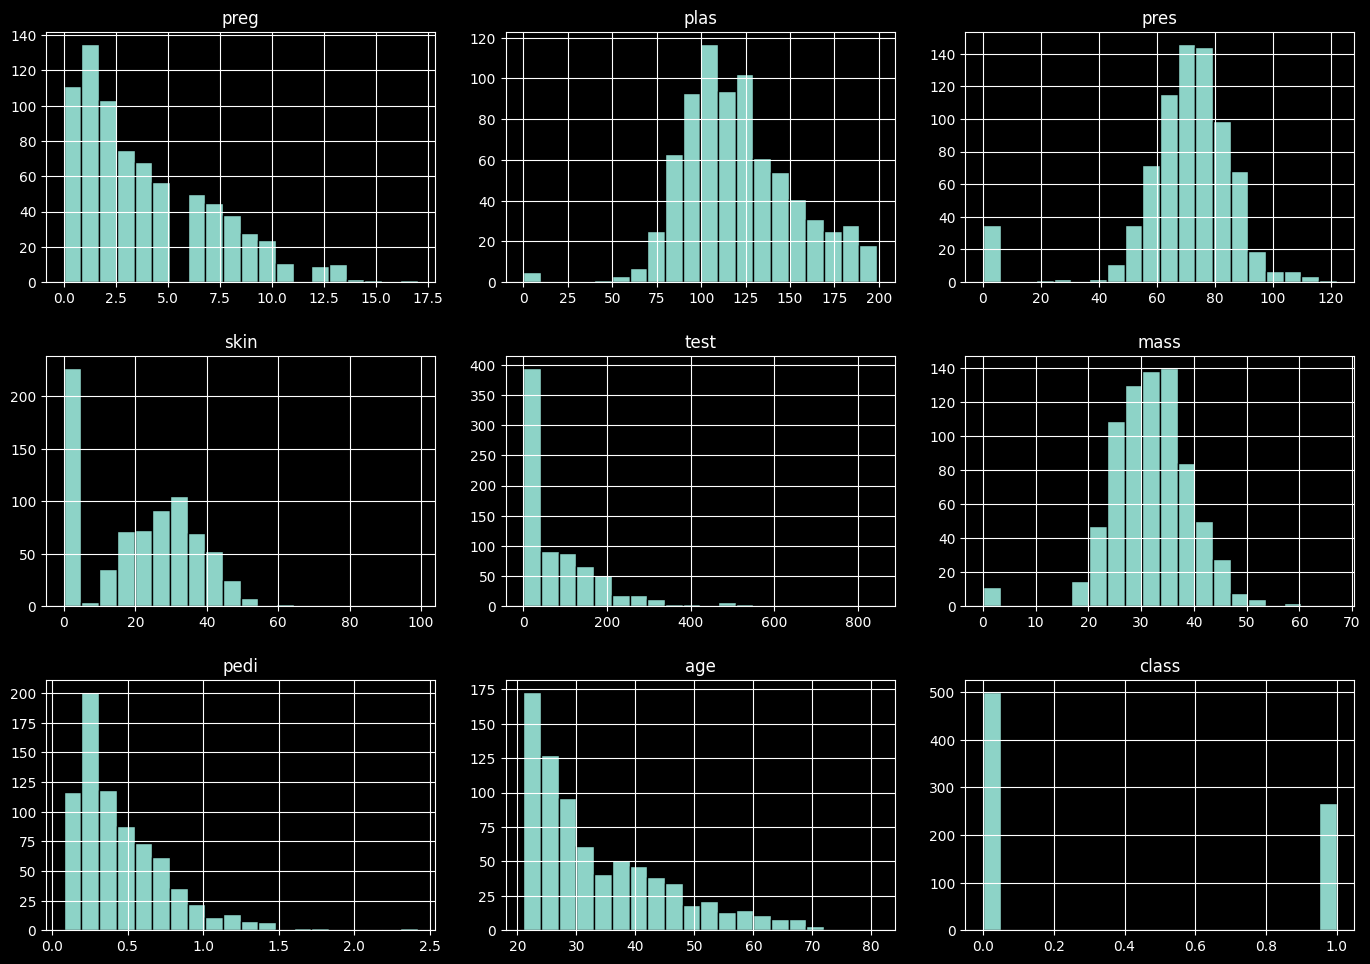

In [9]:
import matplotlib.pyplot as plt

# Histograms for all features with clear spacing
axes = data.hist(figsize=(14, 10), layout=(3, 3), bins=20, edgecolor='black')
plt.tight_layout(pad=2.0, w_pad=2.0, h_pad=2.0)
plt.show()


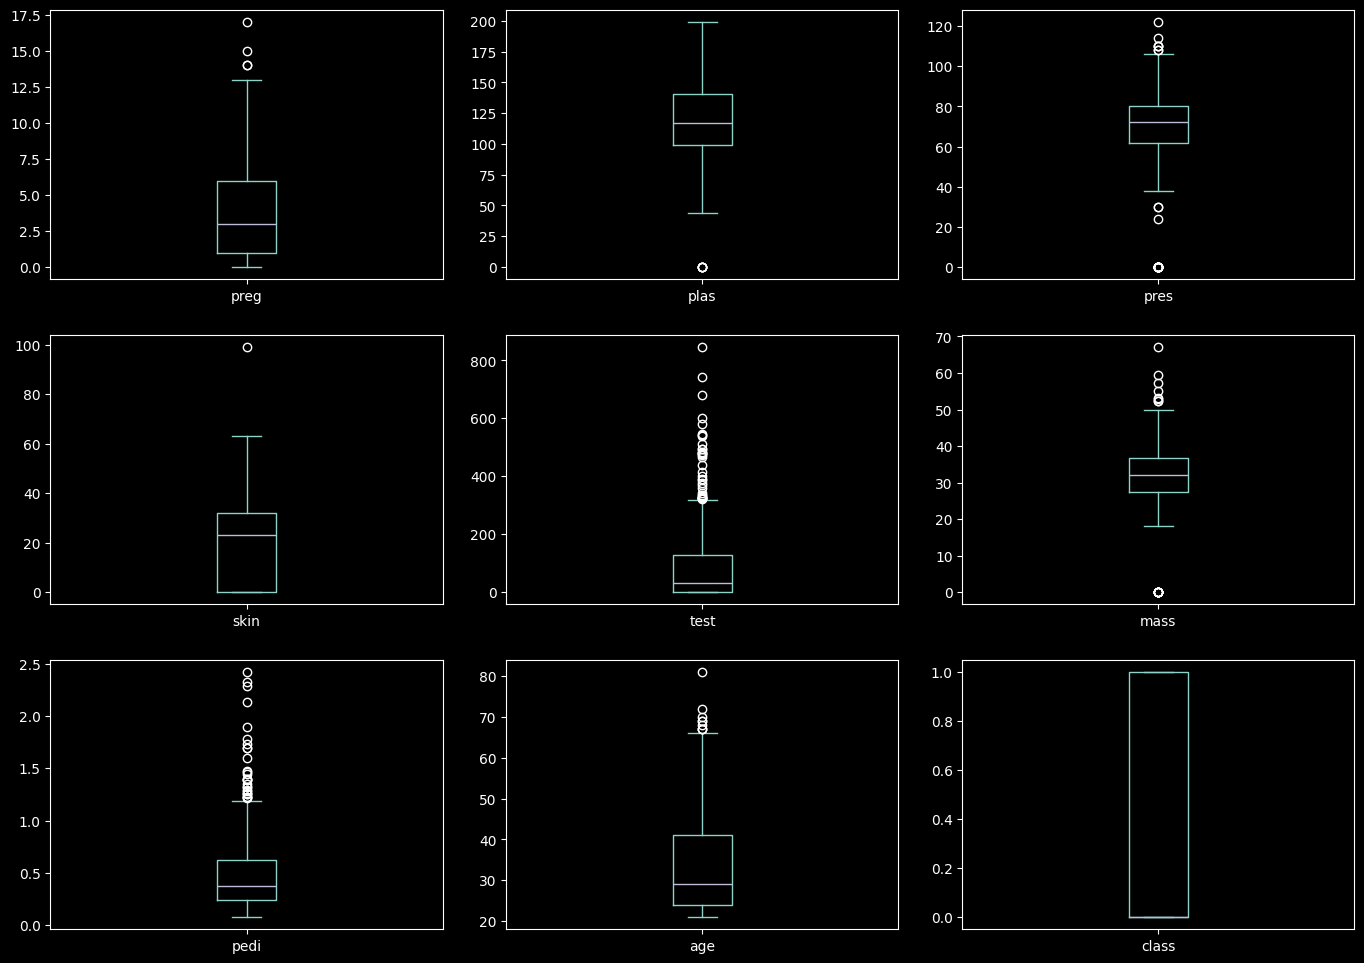

In [10]:
data_plot = data.plot(kind='box', subplots=True, layout=(3,3), sharex=False, figsize=(14,10))
plt.tight_layout(pad=2.0, w_pad=2.0, h_pad=2.0)
plt.show()  

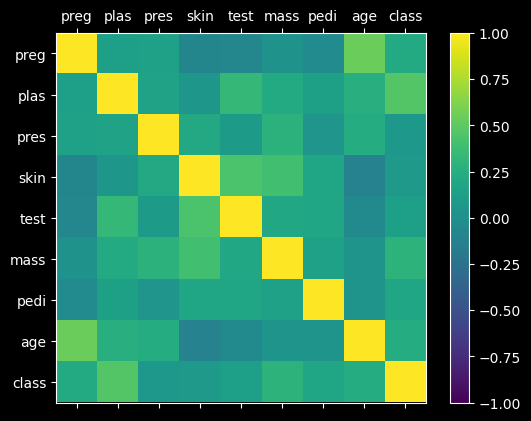

In [11]:
#correlation matrix

correlations = data.corr()
#plot correlation matrix
fig = plt.figure()
ax = fig.add_subplot(111)
cax = ax.matshow(correlations, vmin=-1, vmax=1)
fig.colorbar(cax)
ticks = np.arange(0,9,1)

ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_xticklabels(names)
ax.set_yticklabels(names)
plt.show()


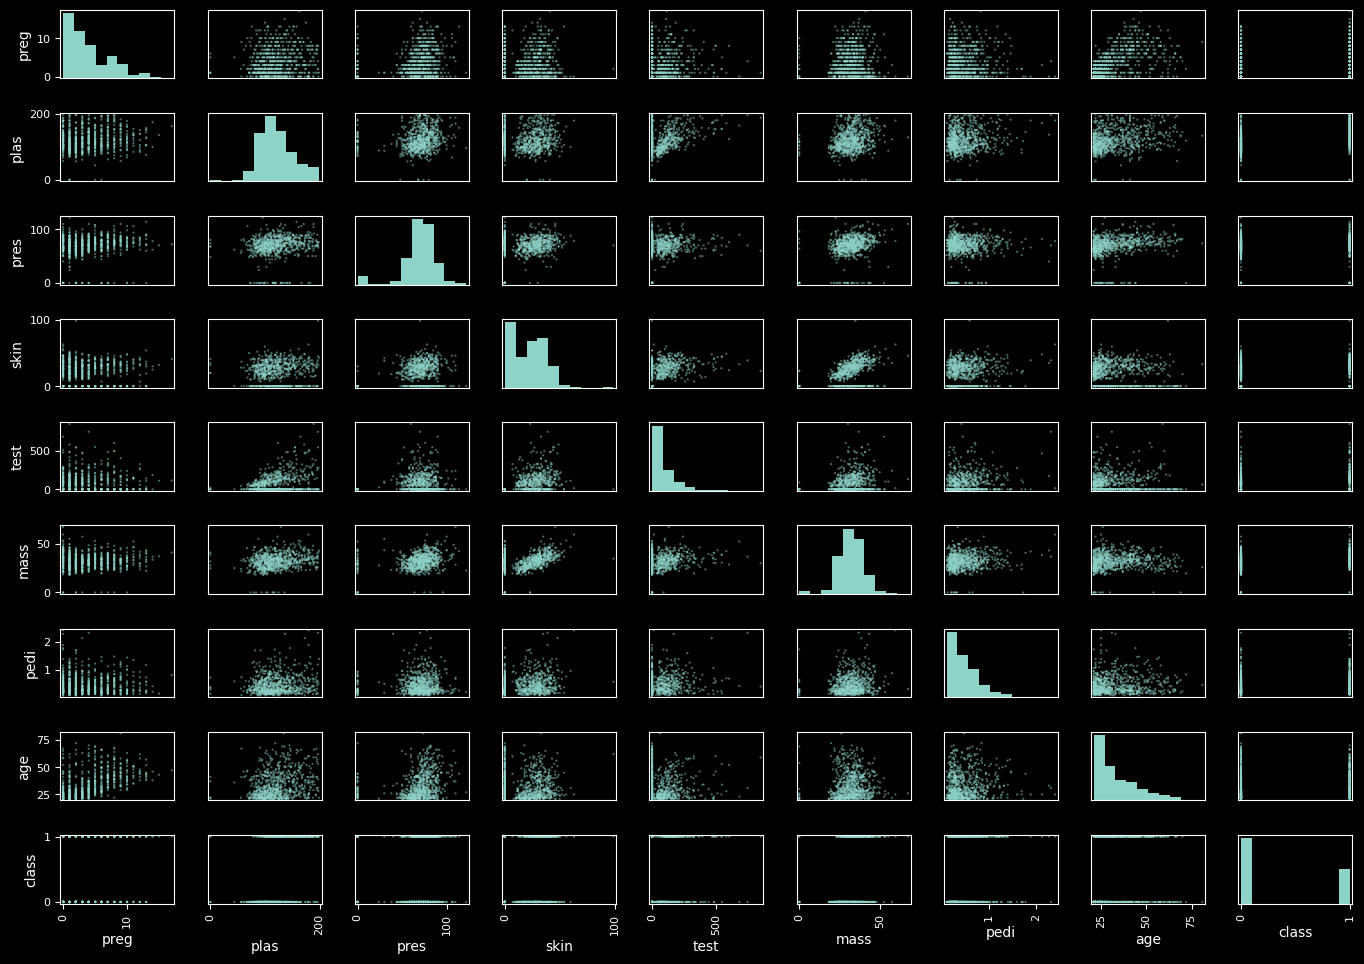

In [12]:
from pandas.plotting import scatter_matrix

# Scatter matrix with better scaling and readability
scatter_matrix(data, figsize=(14, 10), diagonal='hist', marker='.', s=10, alpha=0.5)
plt.tight_layout(pad=2.0)
plt.show()


In [13]:
from sklearn.preprocessing import MinMaxScaler

array = data.values
#sperate array into input and output components
X = array[:,0:8]
Y = array[:,8]
scaler = MinMaxScaler(feature_range=(0,1))
rescaledX = scaler.fit_transform(X)
#summarize transformed data
np.set_printoptions(precision=3)
print(rescaledX[0:5,:])

[[0.353 0.744 0.59  0.354 0.    0.501 0.234 0.483]
 [0.059 0.427 0.541 0.293 0.    0.396 0.117 0.167]
 [0.471 0.92  0.525 0.    0.    0.347 0.254 0.183]
 [0.059 0.447 0.541 0.232 0.111 0.419 0.038 0.   ]
 [0.    0.688 0.328 0.354 0.199 0.642 0.944 0.2  ]]


In [14]:
from sklearn.preprocessing import StandardScaler

#sperate array into input and output components
X = array[:,0:8]
Y = array[:,8]
scaler = StandardScaler().fit(X)
rescaledX = scaler.fit_transform(X)

#summarize transformed data
np.set_printoptions(precision=3)
print(rescaledX[0:5,:])

[[ 0.64   0.848  0.15   0.907 -0.693  0.204  0.468  1.426]
 [-0.845 -1.123 -0.161  0.531 -0.693 -0.684 -0.365 -0.191]
 [ 1.234  1.944 -0.264 -1.288 -0.693 -1.103  0.604 -0.106]
 [-0.845 -0.998 -0.161  0.155  0.123 -0.494 -0.921 -1.042]
 [-1.142  0.504 -1.505  0.907  0.766  1.41   5.485 -0.02 ]]


In [15]:
from sklearn.preprocessing import Normalizer
scaler = Normalizer().fit(X)
normalizedX = scaler.transform(X)
#summarize transformed data
np.set_printoptions(precision=3)
print(normalizedX[0:5,:])

[[0.034 0.828 0.403 0.196 0.    0.188 0.004 0.28 ]
 [0.008 0.716 0.556 0.244 0.    0.224 0.003 0.261]
 [0.04  0.924 0.323 0.    0.    0.118 0.003 0.162]
 [0.007 0.588 0.436 0.152 0.622 0.186 0.001 0.139]
 [0.    0.596 0.174 0.152 0.731 0.188 0.01  0.144]]


In [16]:
from sklearn.preprocessing import Binarizer
binarizer = Binarizer(threshold=0.0).fit(X)
binaryX = binarizer.transform(X)
#summarize transformed data
np.set_printoptions(precision=3)
print(binaryX[0:5,:])

[[1. 1. 1. 1. 0. 1. 1. 1.]
 [1. 1. 1. 1. 0. 1. 1. 1.]
 [1. 1. 1. 0. 0. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]
 [0. 1. 1. 1. 1. 1. 1. 1.]]


In [17]:
# Feature Extraction with Univariate Statistical Tests (Chi-squared for classification)
from pandas import read_csv
from numpy import set_printoptions
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2

# load data
filename = 'pima-indians-diabetes_original.csv'
names = ['preg','plas','pres','skin','test','mass','pedi','age','class']
dataframe = read_csv(filename, header=0, names=names)
array = dataframe.values
X_local = array[:,0:8]
Y_local = array[:,8]

# feature selection
test = SelectKBest(score_func=chi2, k=4)
fit = test.fit(X_local, Y_local)

# summarize scores
set_printoptions(precision=3)
print(fit.scores_)
features = fit.transform(X_local)

# summarize selected features
print(features[0:5,:])


# print selected feature names
selected_indices = test.get_support(indices=True)
selected_feature_names = [names[i] for i in selected_indices]

print("Selected Feature Names:")
print(selected_feature_names)

# transform data
features = test.transform(X_local)

# view first 5 rows
print(features[0:5,:])


[ 111.52  1411.887   17.605   53.108 2175.565  127.669    5.393  181.304]
[[148.    0.   33.6  50. ]
 [ 85.    0.   26.6  31. ]
 [183.    0.   23.3  32. ]
 [ 89.   94.   28.1  21. ]
 [137.  168.   43.1  33. ]]
Selected Feature Names:
['plas', 'test', 'mass', 'age']
[[148.    0.   33.6  50. ]
 [ 85.    0.   26.6  31. ]
 [183.    0.   23.3  32. ]
 [ 89.   94.   28.1  21. ]
 [137.  168.   43.1  33. ]]


/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [18]:
#recursive feature elimination

from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from pandas import read_csv

# load data
filename = 'pima-indians-diabetes_original.csv'
names = ['preg','plas','pres','skin','test','mass','pedi','age','class']
dataframe = read_csv(filename, header=0, names=names)
array = dataframe.values
X = array[:,0:8]
Y = array[:,8]

model = LogisticRegression(max_iter=500)
rfe = RFE(model, n_features_to_select=3)
fit = rfe.fit(X, Y)
print("Num Features: %d" % fit.n_features_)
print("Selected Features: %s" % fit.support_)
print("Feature Ranking: %s" % fit.ranking_)     

Num Features: 3
Selected Features: [ True False False False False  True  True False]
Feature Ranking: [1 2 4 6 5 1 1 3]


/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = 

In [19]:
# Feature Extraction with PCA
from sklearn.decomposition import PCA


# load data
filename = 'pima-indians-diabetes_original.csv'
names = ['preg','plas','pres','skin','test','mass','pedi','age','class']
dataframe = read_csv(filename, header=0, names=names)
array = dataframe.values
X = array[:,0:8]
Y = array[:,8]

#feature extraction
pca = PCA(n_components=3)
fit = pca.fit(X)

#summarize components
print("Explained Variance: %s" % fit.explained_variance_ratio_)
print(fit.components_)



Explained Variance: [0.889 0.062 0.026]
[[-2.022e-03  9.781e-02  1.609e-02  6.076e-02  9.931e-01  1.401e-02
   5.372e-04 -3.565e-03]
 [ 2.265e-02  9.722e-01  1.419e-01 -5.786e-02 -9.463e-02  4.697e-02
   8.168e-04  1.402e-01]
 [ 2.246e-02 -1.434e-01  9.225e-01  3.070e-01 -2.098e-02  1.324e-01
   6.400e-04  1.255e-01]]


In [20]:
# Feature Importance with Extra Trees Classifier
from pandas import read_csv
from sklearn.ensemble import ExtraTreesClassifier
# load data
filename = 'pima-indians-diabetes_original.csv'
names = ['preg','plas','pres','skin','test', 'mass', 'pedi', 'age', 'class']
dataframe = read_csv(filename, header=0, names=names)
array = dataframe.values
X = array[:,0:8]
Y = array[:,8]
# feature extraction
model = ExtraTreesClassifier()
model.fit(X, Y)
print(model.feature_importances_)

[0.106 0.232 0.099 0.078 0.079 0.144 0.117 0.145]


In [21]:
from pandas import read_csv
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

filename = 'pima-indians-diabetes_original.csv'
names = ['preg','plas','pres','skin','test', 'mass', 'pedi', 'age', 'class']
dataframe = read_csv(filename, header=0, names=names)
array = dataframe.values
X = array[:,0:8]
Y = array[:,8]

test_size = 0.33
seed = 7
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=test_size, random_state=seed)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, Y_train)
result = model.score(X_test, Y_test)
print("Accuracy: {:.3f}%".format(result * 100.0))

Accuracy: 78.740%


/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = 

In [22]:
#kfold cross validation
from pandas import read_csv
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression


filename = 'pima-indians-diabetes_original.csv'
names = ['preg','plas','pres','skin','test', 'mass', 'pedi', 'age', 'class']
dataframe = read_csv(filename, header=0, names=names)
array = dataframe.values
X = array[:,0:8]
Y = array[:,8]
num_folds = 10
seed = 7

kfold = KFold(n_splits=num_folds, random_state=seed, shuffle=True)
model = LogisticRegression(max_iter=500)
results = cross_val_score(model, X, Y, cv = kfold)

print("Accuracy: {:.3f}% ({:.3f}%)".format(results.mean()*100.0, results.std()*100.0))

Accuracy: 77.216% (4.968%)


/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = 

In [23]:
#leave one out
from pandas import read_csv
from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression


filename = 'pima-indians-diabetes_original.csv'
names = ['preg','plas','pres','skin','test', 'mass', 'pedi', 'age', 'class']
dataframe = read_csv(filename, header=0, names=names)
array = dataframe.values
X = array[:,0:8]
Y = array[:,8]
loocv = LeaveOneOut()
model = LogisticRegression(max_iter=500)
results = cross_val_score(model, X, Y, cv = loocv)

print("Accuracy: {:.3f}% ({:.3f}%)".format(results.mean()*100.0, results.std()*100.0))

/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = 

Accuracy: 77.604% (41.689%)


/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = 

In [24]:
#repeated random test train splits
from pandas import read_csv
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression


filename = 'pima-indians-diabetes_original.csv'
names = ['preg','plas','pres','skin','test', 'mass', 'pedi', 'age', 'class']
dataframe = read_csv(filename, header=0, names=names)
array = dataframe.values
X = array[:,0:8]
Y = array[:,8]
n_splits = 10
test_size = 0.33
seed = 7
shuffle_split = ShuffleSplit(n_splits=n_splits, test_size=test_size, random_state=seed)
model = LogisticRegression(max_iter=500)
results = cross_val_score(model, X, Y, cv=shuffle_split)

print("Accuracy: {:.3f}% ({:.3f}%)".format(results.mean()*100.0, results.std()*100.0))

/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = 

Accuracy: 76.535% (2.235%)


/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3

Chapter 10


In [25]:
# Cross Validation Classification Accuracy
from pandas import read_csv
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

filename = 'pima-indians-diabetes_original.csv'
names = ['preg','plas','pres','skin','test', 'mass', 'pedi', 'age', 'class']
dataframe = read_csv(filename, header=0, names=names)
array = dataframe.values
X = array[:,0:8]
Y = array[:,8]

kfold = KFold(n_splits=10, shuffle=True, random_state=7)
model = LogisticRegression(max_iter=1000)
scoring ='accuracy'
results = cross_val_score(model, X, Y, cv=kfold, scoring=scoring)
print("Accuracy: %.3f (%.3f)" % (results.mean(), results.std()))

/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = 

Accuracy: 0.772 (0.050)


In [26]:
# Cross Validation Classification LogLoss
from pandas import read_csv
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

filename = 'pima-indians-diabetes_original.csv'
names = ['preg','plas','pres','skin','test', 'mass', 'pedi', 'age', 'class']
dataframe = read_csv(filename, header=0, names=names)
array = dataframe.values
X = array[:,0:8]
Y = array[:,8]


kfold = KFold(n_splits=10, shuffle=True, random_state=7)
model = LogisticRegression(max_iter = 1000)
scoring ='neg_log_loss'
results = cross_val_score(model, X, Y, cv=kfold, scoring=scoring)
print(f"Logloss: {results.mean():.3f} ({results.std():.3f})")

/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = 

Logloss: -0.485 (0.057)


/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = 

In [27]:
# Cross Validation Classification ROC AUC
from pandas import read_csv
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

filename = 'pima-indians-diabetes_original.csv'
names = ['preg','plas','pres','skin','test', 'mass', 'pedi', 'age', 'class']
dataframe = read_csv(filename, header=0, names=names)
array = dataframe.values
X = array[:,0:8]
Y = array[:,8]

kfold = KFold(n_splits=10, shuffle=True, random_state=7)
model = LogisticRegression(max_iter = 1000)

scoring = 'roc_auc'
results = cross_val_score(model, X, Y, cv=kfold, scoring = scoring)
print("AUC: %.3f (%.3f)" % (results.mean(), results.std()))

/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = 

AUC: 0.829 (0.047)


/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = 

In [28]:
# Cross Validation Classification Confusion Matrix
from pandas import read_csv
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

filename = 'pima-indians-diabetes_original.csv'
names = ['preg','plas','pres','skin','test', 'mass', 'pedi', 'age', 'class']
dataframe = read_csv(filename, header=0, names=names)
array = dataframe.values
X = array[:,0:8]
Y = array[:,8]
test_size = 0.33
seed = 7
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=test_size, random_state=seed)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, Y_train)
predicted = model.predict(X_test)
matrix = confusion_matrix(Y_test, predicted)
print(matrix)

[[142  20]
 [ 34  58]]


/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = 

In [29]:
# Cross Validation Classification Report
from pandas import read_csv
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

filename = 'pima-indians-diabetes_original.csv'
names = ['preg','plas','pres','skin','test', 'mass', 'pedi', 'age', 'class']
dataframe = read_csv(filename, header=0, names=names)
array = dataframe.values
X = array[:,0:8]
Y = array[:,8]
test_size = 0.33
seed = 7
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=test_size, random_state=seed)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, Y_train)
predicted = model.predict(X_test)

report = classification_report(Y_test, predicted)
print(report)

              precision    recall  f1-score   support

         0.0       0.81      0.88      0.84       162
         1.0       0.74      0.63      0.68        92

    accuracy                           0.79       254
   macro avg       0.78      0.75      0.76       254
weighted avg       0.78      0.79      0.78       254



/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = 

In [30]:
# Cross Validation Regression MAE
from pandas import read_csv
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

filename = 'pima-indians-diabetes_original.csv'
names = ['preg','plas','pres','skin','test', 'mass', 'pedi', 'age', 'class']
dataframe = read_csv(filename, header=0, names=names)
array = dataframe.values
X = array[:,0:8]
Y = array[:,8]

kfold = KFold(n_splits=10, shuffle=True, random_state=7)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=test_size, random_state=seed)
model = LinearRegression()
scoring = 'neg_mean_absolute_error'
resutls = cross_val_score(model, X, Y, cv = kfold, scoring=scoring)
print("MAE: %.3f (%.3f)" % (results.mean(), results.std()))

MAE: 0.829 (0.047)


In [31]:
# Cross Validation Regression MSE
from pandas import read_csv
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression


filename = 'pima-indians-diabetes_original.csv'
names = ['preg','plas','pres','skin','test', 'mass', 'pedi', 'age', 'class']
dataframe = read_csv(filename, header=0, names=names)
array = dataframe.values
X = array[:,0:8]
Y = array[:,8]

num_folds = 10
kfold = KFold(n_splits = 10, shuffle=True, random_state=7)
model = LinearRegression()
scoring = 'neg_mean_squared_error'
results = cross_val_score(model, X, Y, cv=kfold, scoring=scoring)
print("MSE: %.3f (%.3f)" % (results.mean(), results.std()))

MSE: -0.163 (0.020)


In [32]:
# Cross Validation Regression MSE
from pandas import read_csv
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression


filename = 'pima-indians-diabetes_original.csv'
names = ['preg','plas','pres','skin','test', 'mass', 'pedi', 'age', 'class']
dataframe = read_csv(filename, header=0, names=names)
array = dataframe.values
X = array[:,0:8]
Y = array[:,8]

num_folds = 10
kfold = KFold(n_splits = 10, shuffle=True, random_state=7)
model = LinearRegression()
scoring = 'r2'
results = cross_val_score(model, X, Y, cv=kfold, scoring=scoring)
print("R2: %.3f (%.3f)" % (results.mean(), results.std()))

R2: 0.264 (0.102)


Chapter 11

In [33]:
# Logistic Regression Classification
from pandas import read_csv
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

filename = 'pima-indians-diabetes_original.csv'
names = ['preg','plas','pres','skin','test', 'mass', 'pedi', 'age', 'class']
dataframe = read_csv(filename, header=0, names=names)
array = dataframe.values
X = array[:,0:8]
Y = array[:,8]
num_folds = 10

kfold = KFold(n_splits=10, shuffle = True, random_state=7)
model = LogisticRegression(max_iter=1000)
results = cross_val_score(model, X, Y, cv=kfold)
print(results.mean())

/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = 

0.7721633629528366


/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = 

CHAPTER 12

In [34]:
#Linear Regression
from pandas import read_csv
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

filename = 'pima-indians-diabetes_original.csv'
names = ['preg','plas','pres','skin','test', 'mass', 'pedi', 'age', 'class']
dataframe = read_csv(filename, header=0, names=names)
array = dataframe.values

X = array[:,0:8]
Y = array[:,8]
kfold = KFold(n_splits = 10, shuffle=True, random_state = 7)
model = LinearRegression()
scoring = 'neg_mean_squared_error'
results = cross_val_score(model, X, Y, cv=kfold, scoring=scoring)
print(results.mean())

-0.16320738575907065


In [35]:
#Ridge regression
from pandas import read_csv
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import Ridge

filename = 'pima-indians-diabetes_original.csv'
names = ['preg','plas','pres','skin','test', 'mass', 'pedi', 'age', 'class']
dataframe = read_csv(filename, header=0, names=names)
array = dataframe.values

X = array[:,0:8]
Y = array[:,8]

num_folds = 10
kfold = KFold(n_splits=10, shuffle = True, random_state=7)
model = Ridge()
scoring = 'neg_mean_squared_error'
results = cross_val_score(model, X, Y, cv=kfold, scoring = scoring)
print(results.mean())

-0.16319340068845492


/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py

In [36]:
#Lasso regression
from pandas import read_csv
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import Lasso

filename = 'pima-indians-diabetes_original.csv'
names = ['preg','plas','pres','skin','test', 'mass', 'pedi', 'age', 'class']
dataframe = read_csv(filename, header=0, names=names)
array = dataframe.values

X = array[:,0:8]
Y = array[:,8]

num_folds = 10
kfold = KFold(n_splits=10, shuffle = True, random_state=7)
model = Lasso()
scoring = 'neg_mean_squared_error'
resutls = cross_val_score(model, X, Y, scoring = scoring)
print(results.mean())

-0.16319340068845492


/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/kamruzzamankhanalve/Docu

In [37]:
# ElasticNet Regression
from pandas import read_csv
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import ElasticNet

filename = 'pima-indians-diabetes_original.csv'
names = ['preg','plas','pres','skin','test', 'mass', 'pedi', 'age', 'class']
dataframe = read_csv(filename, header=0, names=names)
array = dataframe.values

X = array[:,0:8]
Y = array[:,8]

num_folds = 10
kfold = KFold(n_splits=10, shuffle = True, random_state=7)
model = ElasticNet()
scoring = 'neg_mean_squared_error'
resutls = cross_val_score(model, X, Y, scoring = scoring)
print(results.mean())

-0.16319340068845492


/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/kamruzzamankhanalve/Docu

In [38]:
# KNN Regression
from pandas import read_csv
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsRegressor

filename = 'pima-indians-diabetes_original.csv'
names = ['preg','plas','pres','skin','test', 'mass', 'pedi', 'age', 'class']
dataframe = read_csv(filename, header=0, names=names)
array = dataframe.values

X = array[:,0:8]
Y = array[:,8]

num_folds = 10
kfold = KFold(n_splits=10, shuffle = True, random_state=7)

model = KNeighborsRegressor()
scoring = 'neg_mean_squared_error'
results = cross_val_score(model, X, Y, scoring = scoring)
print(results.mean())

-0.19984110007639416


In [39]:
# Decision Tree Regression
from pandas import read_csv
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeRegressor

filename = 'pima-indians-diabetes_original.csv'
names = ['preg','plas','pres','skin','test', 'mass', 'pedi', 'age', 'class']
dataframe = read_csv(filename, header=0, names=names)
array = dataframe.values

X = array[:,0:8]
Y = array[:,8]

num_folds = 10
kfold = KFold(n_splits=10, shuffle = True, random_state=7)
model = DecisionTreeRegressor()
scoring = 'neg_mean_squared_error'
results = cross_val_score(model, X, Y, scoring = scoring)
print(results.mean())

-0.29283592224768695


In [40]:
# SVM Regression
from pandas import read_csv
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVR

filename = 'pima-indians-diabetes_original.csv'
names = ['preg','plas','pres','skin','test', 'mass', 'pedi', 'age', 'class']
dataframe = read_csv(filename, header=0, names=names)
array = dataframe.values

X = array[:,0:8]
Y = array[:,8]

num_folds = 10
kfold = KFold(n_splits=10, shuffle = True, random_state=7)

model = SVR()
scoring = 'neg_mean_squared_error'
results = cross_val_score(model, X, Y, scoring = scoring)
print(results.mean())

-0.17452647459481144


CHAPTER 13


/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = 

LR: 0.772163 (0.049684)
LDA: 0.766969 (0.047966)
KNN: 0.710988 (0.050792)
CART: 0.686329 (0.044375)
NB: 0.759142 (0.038960)


/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = 

SVM: 0.760458 (0.034712)


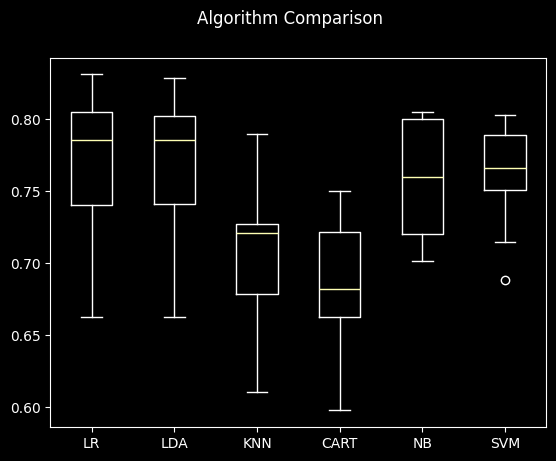

In [41]:
# Compare Algorithms
from pandas import read_csv
from matplotlib import pyplot
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC


filename = 'pima-indians-diabetes_original.csv'
names = ['preg','plas','pres','skin','test', 'mass', 'pedi', 'age', 'class']
dataframe = read_csv(filename, header=0, names=names)
array = dataframe.values

X = array[:,0:8]
Y = array[:,8]

models = []
models.append(('LR', LogisticRegression(max_iter=1000)))
models.append(('LDA', LinearDiscriminantAnalysis()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('NB', GaussianNB()))
models.append(('SVM', SVC()))

results = []
names = []
scoring = 'accuracy'
for name, model in models:
    kfold = KFold(n_splits=10, shuffle=True, random_state=7)
    cv_results = cross_val_score(model, X, Y, cv=kfold, scoring=scoring)
    results.append(cv_results)
    names.append(name)
    msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
    print(msg)
    
fig = pyplot.figure()
fig.suptitle('Algorithm Comparison')
ax = fig.add_subplot(111)
pyplot.boxplot(results)
ax.set_xticklabels(names)
pyplot.show()

CHAPTER 14

In [42]:
# Create a pipeline that standardizes the data then creates a model
from pandas import read_csv
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

filename = 'pima-indians-diabetes_original.csv'
names = ['preg','plas','pres','skin','test', 'mass', 'pedi', 'age', 'class']
dataframe = read_csv(filename, header=0, names=names)
array = dataframe.values

X = array[:,0:8]
Y = array[:,8]


#create pipeline
estimators = []
estimators.append(('standardize', StandardScaler()))
estimators.append(('lda', LinearDiscriminantAnalysis()))
model = Pipeline(estimators)

#evaluate pipeline
kfold = KFold(n_splits=10, shuffle = True, random_state=7)
results = cross_val_score(model, X, Y, cv=kfold)
print(results.mean())

0.7669685577580315


In [43]:
# Create a pipeline that extracts features from the data then creates a model
from pandas import read_csv
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.pipeline import FeatureUnion
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest

filename = 'pima-indians-diabetes_original.csv'
names = ['preg','plas','pres','skin','test', 'mass', 'pedi', 'age', 'class']
dataframe = read_csv(filename, header=0, names=names)
array = dataframe.values

X = array[:,0:8]
Y = array[:,8]

# create feature union
features = []
features.append(('pca', PCA(n_components=3)))
features.append(('select_best', SelectKBest(k=6)))
feature_union = FeatureUnion(features)

# create pipeline
estimators = []
estimators.append(('feature_union', feature_union))
estimators.append(('logistic', LogisticRegression(max_iter=200)))
model = Pipeline(estimators)

# evaluate pipeline
kfold = KFold(n_splits=10, shuffle=True, random_state=7)
results = cross_val_score(model, X, Y, cv=kfold)
print(results.mean())



0.7721633629528366


/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/

CHAPTER 15

In [44]:
# Bagged Decision Trees for Classification
from pandas import read_csv
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

filename = 'pima-indians-diabetes_original.csv'
names = ['preg','plas','pres','skin','test', 'mass', 'pedi', 'age', 'class']
dataframe = read_csv(filename, header=0, names=names)
array = dataframe.values

X = array[:,0:8]
Y = array[:,8]

seed = 7
kfold = KFold(n_splits=101, shuffle=True, random_state=seed)
cart = DecisionTreeClassifier()
num_trees = 100

model = BaggingClassifier(estimator=cart, n_estimators=num_trees, random_state=seed)
results = cross_val_score(model, X, Y, cv=kfold)
print(results.mean())


0.7632602545968882


In [45]:
# Random Forest Classification
from pandas import read_csv
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

filename = 'pima-indians-diabetes_original.csv'
names = ['preg','plas','pres','skin','test', 'mass', 'pedi', 'age', 'class']
dataframe = read_csv(filename, header=0, names=names)
array = dataframe.values

X = array[:,0:8]
Y = array[:,8]

num_trees = 100
max_features = 3
kfold = KFold(n_splits=10, shuffle=True, random_state=7)
model = RandomForestClassifier(n_estimators=num_trees, max_features=max_features)
results = cross_val_score(model, X, Y, cv=kfold)
print(results.mean())

0.7708646616541355


In [46]:
# Extra Trees Classification
from pandas import read_csv
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import ExtraTreesClassifier

filename = 'pima-indians-diabetes_original.csv'
names = ['preg','plas','pres','skin','test', 'mass', 'pedi', 'age', 'class']
dataframe = read_csv(filename, header=0, names=names)
array = dataframe.values

X = array[:,0:8]
Y = array[:,8]

num_trees = 100
max_features = 3
kfold = KFold(n_splits=10, shuffle=True, random_state=7)
model = ExtraTreesClassifier(n_estimators=num_trees, max_features=max_features)
results = cross_val_score(model, X, Y, cv=kfold)
print(results.mean())

0.7526315789473684


In [47]:
# AdaBoost Classification
from pandas import read_csv
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import AdaBoostClassifier

X = array[:,0:8]
Y = array[:,8]

num_trees = 30
max_features = 3
seed = 7
kfold = KFold(n_splits=10, shuffle=True, random_state=seed)

# Newer scikit-learn versions no longer accept the 'algorithm' argument here
model = AdaBoostClassifier(
    n_estimators=num_trees,
    random_state=seed,
)
results = cross_val_score(model, X, Y, cv=kfold)
print(results.mean())

0.7552460697197538


In [48]:
# Stochastic Gradient Boosting Classification
from pandas import read_csv
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import GradientBoostingClassifier

X = array[:,0:8]
Y = array[:,8]

num_trees = 30
seed = 7
kfold = KFold(n_splits=10, shuffle=True, random_state=seed)
model = GradientBoostingClassifier(n_estimators=num_trees, random_state=seed)
results = cross_val_score(model, X, Y, cv=kfold)
print(results.mean())

0.7591763499658237


In [49]:
# Voting Ensemble for Classification
from pandas import read_csv
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier

X = array[:,0:8]
Y = array[:,8]
kfold = KFold(n_splits=10, shuffle=True, random_state=7)

#create the sub models
estimators = []
model1 = LogisticRegression(max_iter=1000)
estimators.append(('logistic', model1))
model2 = DecisionTreeClassifier()
estimators.append(('cart', model2))
model3 = SVC()
estimators.append(('svm', model3))

ensemble = VotingClassifier(estimators)
results = cross_val_score(ensemble, X, Y, cv=kfold)
print(results.mean())

0.7721804511278197


/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = 

CHAPTER 16

In [50]:
# Grid Search for Algorithm Tuning
import numpy
from pandas import read_csv
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

X = array[:,0:8]
Y = array[:,8]

alphas = numpy.array([1,0.1,0.01,0.001,0.0001,0])
param_grid = dict(alpha=alphas)
model = Ridge()
grid = GridSearchCV(estimator=model, param_grid=param_grid)
grid.fit(X, Y)
print(grid.best_score_)
print(grid.best_estimator_.alpha)

0.2761084412929244
1.0


/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packa

In [51]:
# Randomized for Algorithm Tuning
import numpy
from pandas import read_csv
from scipy.stats import uniform
from sklearn.linear_model import Ridge
from sklearn.model_selection import RandomizedSearchCV

X = array[:,0:8]
Y = array[:,8]

param_grid = {'alpha': uniform()}
model = Ridge()
rsearch = RandomizedSearchCV(estimator=model, param_distributions=param_grid, n_iter=100, random_state=7)
rsearch.fit(X, Y)
print(rsearch.best_score_)
print(rsearch.best_estimator_.alpha)

/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packa

0.27610755734028536
0.9779895119966027


/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packa

CHAPTER 16


In [52]:
# Grid Search for Algorithm Tuning
import numpy
from pandas import read_csv
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

X = array[:,0:8]
Y = array[:,8]

alphas = numpy.array([1,0.1,0.01,0.001,0.0001,0])
param_grid = dict(alpha=alphas)

model = Ridge()
grid = GridSearchCV(estimator=model, param_grid=param_grid)
grid.fit(X, Y)
print(grid.best_score_)
print(grid.best_estimator_.alpha)

0.2761084412929244
1.0


/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packa

In [53]:
# Randomized for Algorithm Tuning
import numpy
from pandas import read_csv
from scipy.stats import uniform
from sklearn.linear_model import Ridge
from sklearn.model_selection import RandomizedSearchCV

X = array[:,0:8]
Y = array[:,8]

param_grid = {'alpha': uniform()}
model = Ridge()
rsearch = RandomizedSearchCV(estimator=model, param_distributions=param_grid, n_iter=100, random_state=7)
rsearch.fit(X, Y)
print(rsearch.best_score_)
print(rsearch.best_estimator_.alpha)




/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packa

0.27610755734028536
0.9779895119966027


/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packa

CHAPTER 17

In [54]:
# Save Model Using Pickle
from pandas import read_csv
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from pickle import dump
from pickle import load


X = array[:,0:8]
Y = array[:,8]


X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.33, random_state=7)
# Fit the model on 33%
model = LogisticRegression(max_iter=1000)
model.fit(X_train, Y_train)
# save the model to disk
filename = 'finalized_model.sav'
dump(model, open(filename,'wb'))



# some time later...
# load the model from disk
loaded_model = load(open(filename,'rb'))
result = loaded_model.score(X_test, Y_test)
print(result)

0.7874015748031497


/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = 

CHAPTER 18

CHAPTER 20


In [55]:
# Load libraries
from pandas import read_csv
from pandas.plotting import scatter_matrix
from matplotlib import pyplot
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

In [56]:
filename = 'pima-indians-diabetes_original.csv'
names = ['preg','plas','pres','skin','test', 'mass', 'pedi', 'age', 'class']

dataset = read_csv(filename, names=names, header=0)

#shape 
print(dataset.shape)
print(dataset.head(20))
print(dataset.describe())


(768, 9)
    preg  plas  pres  skin  test  mass   pedi  age  class
0      6   148    72    35     0  33.6  0.627   50      1
1      1    85    66    29     0  26.6  0.351   31      0
2      8   183    64     0     0  23.3  0.672   32      1
3      1    89    66    23    94  28.1  0.167   21      0
4      0   137    40    35   168  43.1  2.288   33      1
5      5   116    74     0     0  25.6  0.201   30      0
6      3    78    50    32    88  31.0  0.248   26      1
7     10   115     0     0     0  35.3  0.134   29      0
8      2   197    70    45   543  30.5  0.158   53      1
9      8   125    96     0     0   0.0  0.232   54      1
10     4   110    92     0     0  37.6  0.191   30      0
11    10   168    74     0     0  38.0  0.537   34      1
12    10   139    80     0     0  27.1  1.441   57      0
13     1   189    60    23   846  30.1  0.398   59      1
14     5   166    72    19   175  25.8  0.587   51      1
15     7   100     0     0     0  30.0  0.484   32      1
16   

In [57]:
#class distribution

print(dataset.groupby('class').size())

class
0    500
1    268
dtype: int64


preg        Axes(0.125,0.653529;0.227941x0.226471)
plas     Axes(0.398529,0.653529;0.227941x0.226471)
pres     Axes(0.672059,0.653529;0.227941x0.226471)
skin        Axes(0.125,0.381765;0.227941x0.226471)
test     Axes(0.398529,0.381765;0.227941x0.226471)
mass     Axes(0.672059,0.381765;0.227941x0.226471)
pedi            Axes(0.125,0.11;0.227941x0.226471)
age          Axes(0.398529,0.11;0.227941x0.226471)
class        Axes(0.672059,0.11;0.227941x0.226471)
dtype: object

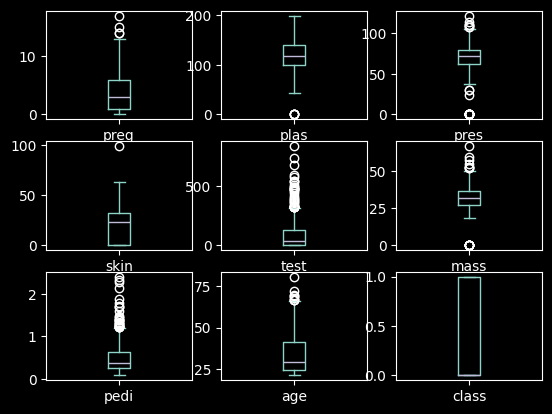

In [58]:
dataset.plot(kind='box', subplots=True, layout=(3,3), sharex=False, sharey=False)

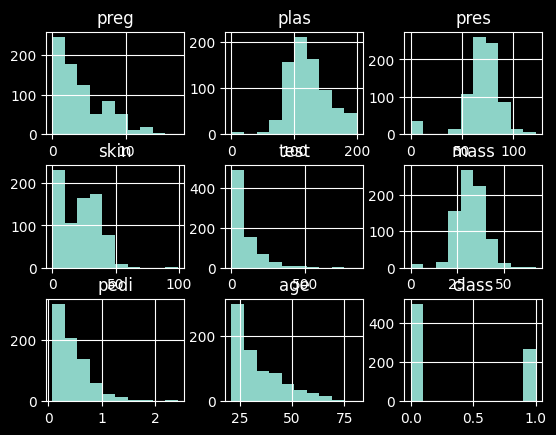

In [59]:
dataset.hist()
pyplot.show()

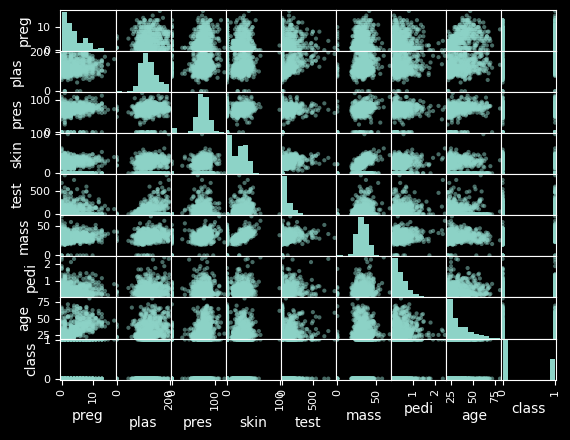

In [60]:
scatter_matrix(dataset)
pyplot.show()

In [61]:
#split out validation dataset
array = dataset.values
X = array[:,0:8]
Y = array[:,8]
validation_size = 0.2
seed = 7
X_train, X_validation, Y_train, Y_validation = train_test_split(X, Y, test_size=validation_size, random_state=seed)

In [62]:
# Spot-Check Algorithms
models = []
models.append(('LR', LogisticRegression()))
models.append(('LDA', LinearDiscriminantAnalysis()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('NB', GaussianNB()))
models.append(('SVM', SVC()))

# evaluate each model in turn
results = []
names = []

for name, model in models:
    kfold = KFold(n_splits=10, shuffle=True, random_state=seed)
    cv_results = cross_val_score(model, X_train, Y_train, cv=kfold, scoring='accuracy')
    results.append(cv_results)
    names.append(name)
    msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
    print(msg)

LR: 0.773850 (0.035887)
LDA: 0.770756 (0.058514)
KNN: 0.710206 (0.049772)
CART: 0.687546 (0.053813)
NB: 0.749418 (0.041042)
SVM: 0.752723 (0.045559)


/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = 

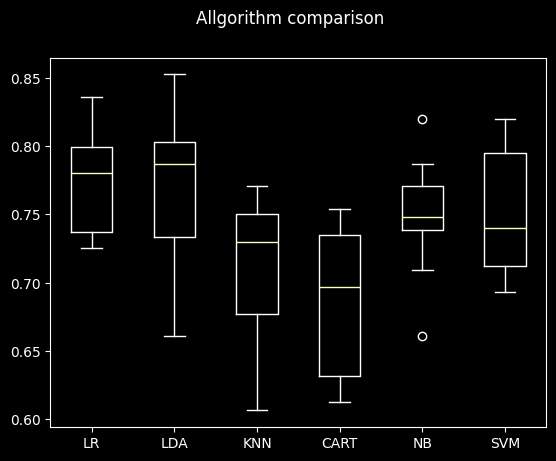

In [63]:
#compare algorithms
fig = pyplot.figure()
fig.suptitle('Allgorithm comparison')
ax = fig.add_subplot(111)
pyplot.boxplot(results)
ax.set_xticklabels(names)
pyplot.show()


In [64]:
knn = KNeighborsClassifier()
knn.fit(X_train, Y_train)
predictions = knn.predict(X_validation)
print(accuracy_score(Y_validation, predictions))
print(confusion_matrix(Y_validation, predictions))
print(classification_report(Y_validation, predictions))

0.7077922077922078
[[82 15]
 [30 27]]
              precision    recall  f1-score   support

         0.0       0.73      0.85      0.78        97
         1.0       0.64      0.47      0.55        57

    accuracy                           0.71       154
   macro avg       0.69      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154

